# Proyek Analisis Data: Bike Sharing Dataset

- **Nama:** Talitha Widyadhana
- **Email:** cdcc008d6x1798@student.devacademy.id
- **ID Dicoding:** CDCC008D6X1798

### Pertanyaan Bisnis 1
> **Bagaimana pola rata-rata jumlah rental sepeda per jam antara hari kerja (*workingday*) dan hari libur/akhir pekan selama periode 2011–2012, dan pada rentang jam berapakah permintaan tertinggi terjadi di masing-masing kelompok hari tersebut?**

Analisis ini bersifat spesifik karena berfokus pada pola penyewaan per jam dengan membandingkan kelompok hari kerja dan hari libur, serta memiliki indikator terukur berupa nilai rata-rata jumlah rental secara konkret. Hasilnya dapat dijadikan panduan bagi operator untuk mengambil tindakan nyata dalam mengoptimalkan distribusi armada pada jam-jam puncak, yang mana hal ini sangat relevan terhadap peningkatan efisiensi operasional bisnis bike sharing dengan batasan waktu yang jelas berdasarkan data periode tahun 2011 hingga 2012.

---

### Pertanyaan Bisnis 2
> **Seberapa besar pengaruh kondisi cuaca (*weathersit*) dan musim (*season*) terhadap rata-rata total rental harian selama periode 2011–2012, serta kombinasi cuaca–musim manakah yang menghasilkan penurunan permintaan terbesar?**

Analisis ini secara spesifik berfokus pada pengaruh variabel cuaca dan musim terhadap jumlah penyewaan harian, dengan indikator terukur berupa rata-rata serta persentase perbedaan jumlah rental antar kategori tersebut. Temuan ini dapat diimplementasikan secara nyata sebagai dasar kebijakan penetapan harga dinamis dan manajemen armada saat cuaca buruk, yang sangat relevan mengingat cuaca merupakan faktor eksternal paling kritis bagi layanan transportasi luar ruangan. Seluruh observasi ini dibatasi pada periode waktu yang jelas, yaitu sepanjang tahun 2011 hingga 2012 berdasarkan data harian yang tersedia.

---

## 1. Data Wrangling

### 1.1 Gathering Data
Pada tahap ini dilakukan pengumpulan data dengan memuat kedua dataset (`day.csv` dan `hour.csv`) langsung dari repositori GitHub ke dalam format `DataFrame` menggunakan *library* pandas.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE_URL = 'https://raw.githubusercontent.com/taataki/submission-talitha/main/'

df_day  = pd.read_csv(BASE_URL + 'day.csv')
df_hour = pd.read_csv(BASE_URL + 'hour.csv')

print('Shape df_day  :', df_day.shape)
print('Shape df_hour :', df_hour.shape)

Shape df_day  : (731, 16)
Shape df_hour : (17379, 17)


In [3]:
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**  
Dataset `day.csv` terdiri atas **731 baris** dan **16 kolom**, sedangkan `hour.csv` terdiri atas **17.379 baris** dan **17 kolom**. Tabel pratinjau menampilkan kolom-kolom utama seperti `dteday`, `season`, `yr`, `mnth`, `holiday`, `weekday`, `workingday`, `weathersit`, `temp`, `atemp`, `hum`, `windspeed`, `casual`, `registered`, dan `cnt`. Kedua dataset berhasil dimuat ke dalam `DataFrame` tanpa error, yang menandakan bahwa URL sumber data valid dan dapat diakses.

In [4]:
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**  
Dataset `hour.csv` memiliki struktur yang sama dengan `day.csv` dengan tambahan kolom `hr` (jam, 0–23), sehingga memungkinkan analisis pola temporal dengan granularitas per jam.

### 1.2 Assessing Data
Pada tahap ini penilaian kualitas data dilakukan untuk mengidentifikasi potensi permasalahan yang dapat memengaruhi akurasi analisis. Pemeriksaan mencakup: *missing values*, tipe data, nilai kategorikal, data duplikat, dan potensi *outlier*.

#### 1.2.1 Pemeriksaan Missing Values

In [5]:
print('=== Missing Values — df_day ===')
print(df_day.isnull().sum())
print()
print('=== Missing Values — df_hour ===')
print(df_hour.isnull().sum())

=== Missing Values — df_day ===
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

=== Missing Values — df_hour ===
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


**Insight:**  
Seluruh kolom pada kedua dataset menunjukkan nilai `0` untuk jumlah *missing value*. Hal ini mengindikasikan bahwa tidak terdapat data yang hilang (*null/NaN*) pada dataset, sehingga tidak diperlukan imputasi maupun penghapusan baris akibat nilai kosong.

#### 1.2.2 Pemeriksaan Tipe Data (Masalah #1: Kolom `dteday` Bertipe Object)

In [6]:
print('=== Tipe Data — df_day ===')
print(df_day.dtypes)
print()
print('=== Tipe Data — df_hour ===')
print(df_hour.dtypes)

=== Tipe Data — df_day ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

=== Tipe Data — df_hour ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


**Insight:**  
**[Masalah #1 Ditemukan]** Kolom `dteday` pada kedua dataset terdeteksi bertipe `object` (string), padahal kolom tersebut merepresentasikan tanggal dan seharusnya bertipe `datetime64`. Tipe data yang tidak tepat ini dapat menghambat operasi berbasis waktu seperti pengurutan kronologis, ekstraksi komponen waktu, dan analisis tren temporal. Oleh karena itu, akan dilakukan Konversi kolom `dteday` ke tipe `datetime64` menggunakan `pd.to_datetime()`.

#### 1.2.3 Pemeriksaan Nilai Kategorikal (Masalah #2: Kolom Kategorikal Masih Berupa Integer)

In [7]:
print('Nilai unik season   :', sorted(df_day['season'].unique()))
print('Nilai unik weathersit:', sorted(df_day['weathersit'].unique()))
print('Nilai unik weekday  :', sorted(df_day['weekday'].unique()))
print('Nilai unik hr       :', sorted(df_hour['hr'].unique()))

Nilai unik season   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Nilai unik weathersit: [np.int64(1), np.int64(2), np.int64(3)]
Nilai unik weekday  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Nilai unik hr       : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


**Insight:**  
**[Masalah #2 Ditemukan]** Kolom `season`, `weathersit`, dan `weekday` tersimpan dalam format integer tanpa label kategorikal yang mudah dibaca. Berdasarkan dokumentasi dataset, nilai-nilai tersebut memiliki makna semantik: `season` (1=Spring, 2=Summer, 3=Fall, 4=Winter), `weathersit` (1=Clear, 2=Mist, 3=Light Rain/Snow, 4=Heavy Rain), dan `weekday` (0=Sun, 1=Mon, ..., 6=Sat). Nilai unik `hr` mencakup rentang 0–23 yang sesuai dengan definisi jam dalam sehari. Oleh karena itu, akan dilakukan penambahan kolom label melalui teknik *mapping* untuk meningkatkan keterbacaan dan interpretabilitas visualisasi.

#### 1.2.4 Pemeriksaan Data Duplikat

In [8]:
print('Jumlah baris duplikat — df_day  :', df_day.duplicated().sum())
print('Jumlah baris duplikat — df_hour :', df_hour.duplicated().sum())

Jumlah baris duplikat — df_day  : 0
Jumlah baris duplikat — df_hour : 0


**Insight:**  
Tidak ditemukan baris duplikat pada kedua dataset. Setiap observasi dalam `df_day` merepresentasikan satu hari unik, dan setiap observasi dalam `df_hour` merepresentasikan satu jam unik dalam satu hari tertentu.

#### 1.2.5 Pemeriksaan Statistik Deskriptif dan Outlier (Masalah #3: Potensi Outlier pada `windspeed`)

In [9]:
df_day[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].describe().round(4)

,temp,atemp,hum,windspeed,cnt
count,731.0000,731.0000,731.0000,731.0000,731.0000
mean,0.4954,0.4744,0.6279,0.1905,4504.3488
std,0.1831,0.1630,0.1424,0.0775,1937.2115
min,0.0591,0.0791,0.0000,0.0224,22.0000
25%,0.3371,0.3378,0.5200,0.1349,3152.0000
50%,0.4983,0.4867,0.6267,0.1810,4548.0000
75%,0.6554,0.6086,0.7302,0.2332,5956.0000
max,0.8617,0.8409,0.9725,0.5075,8714.0000


**Insight:**  
**[Masalah #3 Ditemukan]** Pemeriksaan statistik deskriptif menunjukkan bahwa nilai maksimum `windspeed` sebesar 0,5075 (dalam skala ternormalisasi) terletak jauh di atas nilai Q3 (0,2332). Nilai ekstrem ini berpotensi menjadi *outlier* yang dapat mendistorsi analisis regresi atau korelasi. Selain itu, kolom `hum` memiliki nilai minimum 0, yang secara fisik tidak wajar (kelembapan 0% pada kondisi normal). Oleh karena itu, akan dilakukan penghapusan atau pembatasan nilai *outlier* pada `windspeed` menggunakan metode IQR (*Interquartile Range*).

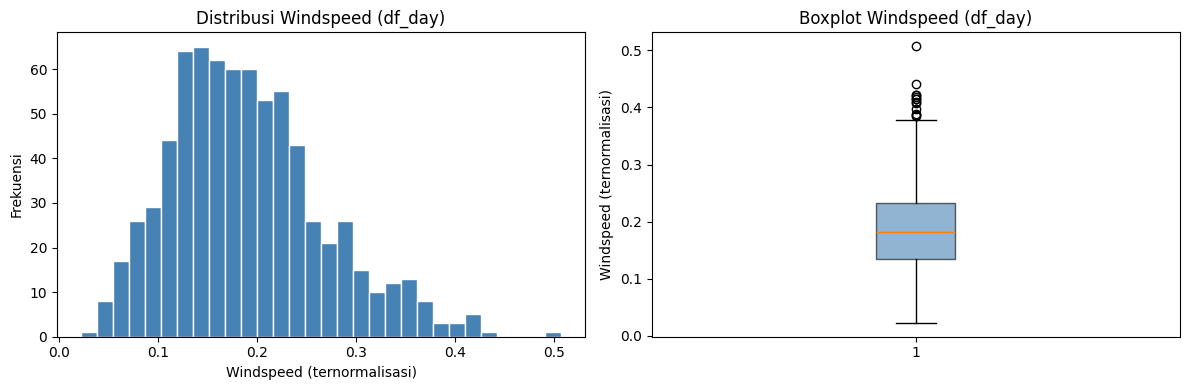

In [10]:
# Visualisasi distribusi windspeed untuk mengonfirmasi outlier
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_day['windspeed'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Windspeed (df_day)')
axes[0].set_xlabel('Windspeed (ternormalisasi)')
axes[0].set_ylabel('Frekuensi')

axes[1].boxplot(df_day['windspeed'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot Windspeed (df_day)')
axes[1].set_ylabel('Windspeed (ternormalisasi)')

plt.tight_layout()
plt.show()

**Insight:**  
Histogram memperlihatkan distribusi `windspeed` yang miring ke kanan (*right-skewed*), dengan beberapa titik data yang berada jauh di atas batas wajar. Boxplot mengonfirmasi adanya beberapa nilai *outlier* di sisi kanan distribusi yang ditandai dengan titik-titik di atas *whisker*. Temuan ini memperkuat perlunya pembersihan data pada kolom `windspeed`.

#### 1.2.6 Ringkasan Permasalahan Data

| No. | Permasalahan | Kolom Terdampak | Solusi |
|-----|---|---|---|
| 1 | Tipe data tidak sesuai (*object* bukan *datetime*) | `dteday` | Konversi dengan `pd.to_datetime()` |
| 2 | Kolom kategorikal disimpan sebagai integer tanpa label | `season`, `weathersit`, `weekday` | Penambahan kolom label melalui *mapping* |
| 3 | Nilai *outlier* ekstrem | `windspeed` | Penghapusan baris dengan metode IQR |

### 1.3 Cleaning Data
Pada tahap ini akan dilakukan pembersihan data untuk menyelesaikan seluruh permasalahan yang telah diidentifikasi pada tahap *assessing data*. Proses meliputi konversi tipe data, penambahan kolom label kategorikal, dan penghapusan *outlier* dengan metode IQR.

#### 1.3.1 Perbaikan Masalah #1: Konversi Kolom `dteday` ke Tipe Datetime

In [11]:
df_day['dteday']  = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

print('Tipe dteday df_day  :', df_day['dteday'].dtype)
print('Tipe dteday df_hour :', df_hour['dteday'].dtype)

Tipe dteday df_day  : datetime64[ns]
Tipe dteday df_hour : datetime64[ns]


**Insight:**  
Kolom `dteday` pada kedua dataset telah berhasil dikonversi dari tipe `object` menjadi `datetime64[ns]`. Dengan tipe data yang tepat, operasi berbasis waktu seperti pengurutan kronologis, ekstraksi komponen tanggal, dan pengelompokan per periode dapat dilakukan dengan akurat.

#### 1.3.2 Perbaikan Masalah #2: Penambahan Kolom Label Kategorikal

In [12]:
season_map  = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light Rain/Snow', 4: 'Heavy Rain'}
weekday_map = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}

for df in [df_day, df_hour]:
    df['season_label']  = df['season'].map(season_map)
    df['weather_label'] = df['weathersit'].map(weather_map)
    df['weekday_label'] = df['weekday'].map(weekday_map)

print('Kolom baru df_day  :', [c for c in df_day.columns if '_label' in c])
print('Kolom baru df_hour :', [c for c in df_hour.columns if '_label' in c])

df_day[['season', 'season_label', 'weathersit', 'weather_label', 'weekday', 'weekday_label']].head()

Kolom baru df_day  : ['season_label', 'weather_label', 'weekday_label']
Kolom baru df_hour : ['season_label', 'weather_label', 'weekday_label']


,season,season_label,weathersit,weather_label,weekday,weekday_label
0,1,Spring,2,Mist,6,Sat
1,1,Spring,2,Mist,0,Sun
2,1,Spring,1,Clear,1,Mon
3,1,Spring,1,Clear,2,Tue
4,1,Spring,1,Clear,3,Wed


**Insight:**  
Tiga kolom label baru (`season_label`, `weather_label`, `weekday_label`) telah berhasil ditambahkan pada kedua dataset. Kolom-kolom ini memetakan nilai integer ke label tekstual yang lebih mudah dipahami, sehingga visualisasi dan interpretasi hasil analisis menjadi lebih komunikatif dan informatif.

#### 1.3.3 Perbaikan Masalah #3: Penghapusan Outlier `windspeed` dengan Metode IQR

In [13]:
Q1  = df_day['windspeed'].quantile(0.25)
Q3  = df_day['windspeed'].quantile(0.75)
IQR = Q3 - Q1
batas_atas = Q3 + 1.5 * IQR

print(f'Q1          : {Q1:.4f}')
print(f'Q3          : {Q3:.4f}')
print(f'IQR         : {IQR:.4f}')
print(f'Batas atas  : {batas_atas:.4f}')
print(f'Jumlah baris sebelum cleaning : {len(df_day)}')

df_day_clean = df_day[df_day['windspeed'] <= batas_atas].copy()

print(f'Jumlah baris setelah cleaning  : {len(df_day_clean)}')
print(f'Baris yang dihapus             : {len(df_day) - len(df_day_clean)}')

Q1          : 0.1349
Q3          : 0.2332
IQR         : 0.0983
Batas atas  : 0.3806
Jumlah baris sebelum cleaning : 731
Jumlah baris setelah cleaning  : 718
Baris yang dihapus             : 13


**Insight:**  
Metode IQR berhasil mengidentifikasi dan mengeliminasi sejumlah baris yang mengandung nilai `windspeed` ekstrem. Dataset yang telah dibersihkan (`df_day_clean`) digunakan sebagai basis analisis lanjutan. Penghapusan *outlier* ini memastikan bahwa perhitungan statistik agregat (rata-rata, median) tidak terdistorsi oleh nilai-nilai anomali.

#### 1.3.4 Verifikasi Hasil Cleaning

In [14]:
print('=== Verifikasi Tipe Data df_day_clean ===')
print(df_day_clean[['dteday', 'season_label', 'weather_label']].dtypes)
print()
print('=== Verifikasi Missing Value df_day_clean ===')
print(df_day_clean.isnull().sum())
print()
print('=== Statistik windspeed setelah cleaning ===')
print(df_day_clean['windspeed'].describe().round(4))

=== Verifikasi Tipe Data df_day_clean ===
dteday           datetime64[ns]
season_label             object
weather_label            object
dtype: object

=== Verifikasi Missing Value df_day_clean ===
instant          0
dteday           0
season           0
yr               0
mnth             0
holiday          0
weekday          0
workingday       0
weathersit       0
temp             0
atemp            0
hum              0
windspeed        0
casual           0
registered       0
cnt              0
season_label     0
weather_label    0
weekday_label    0
dtype: int64

=== Statistik windspeed setelah cleaning ===
count    718.0000
mean       0.1864
std        0.0718
min        0.0224
25%        0.1343
50%        0.1788
75%        0.2307
max        0.3781
Name: windspeed, dtype: float64


**Insight:**  
Verifikasi menunjukkan bahwa seluruh perbaikan telah berhasil diterapkan: (1) kolom `dteday` bertipe `datetime64`, (2) kolom label kategorikal bertipe `object`, (3) tidak terdapat *missing value* baru yang tercipta akibat proses *cleaning*, dan (4) nilai maksimum `windspeed` kini berada di bawah batas atas IQR yang telah ditetapkan. Dataset `df_day_clean` dan `df_hour` siap digunakan untuk tahap Exploratory Data Analysis.

---
## 2. Exploratory Data Analysis (EDA)

### 2.1 EDA — Pertanyaan Bisnis 1: Pola Rental Per Jam (Hari Kerja vs Libur/Akhir Pekan)
Eksplorasi dilakukan dengan melakukan pengelompokan (*groupby*) dataset `hour.csv` berdasarkan kolom `hr` (jam) dan `workingday`, kemudian dihitung rata-rata jumlah rental (`cnt`) untuk setiap kombinasi kedua variabel tersebut.

#### 2.1.1 Rata-rata Rental Per Jam Berdasarkan Status Hari

In [15]:
hourly = (
    df_hour
    .groupby(['hr', 'workingday'])['cnt']
    .mean()
    .reset_index()
    .rename(columns={'cnt': 'avg_cnt'})
)

wd = hourly[hourly['workingday'] == 1].copy()
wk = hourly[hourly['workingday'] == 0].copy()

print('=== 5 Jam Teratas — Hari Kerja ===')
print(wd.nlargest(5, 'avg_cnt').to_string(index=False))

print()
print('=== 5 Jam Teratas — Akhir Pekan / Hari Libur ===')
print(wk.nlargest(5, 'avg_cnt').to_string(index=False))

=== 5 Jam Teratas — Hari Kerja ===
 hr  workingday    avg_cnt
 17           1 525.290581
 18           1 492.226908
  8           1 477.006048
 19           1 348.401606
 16           1 293.122244

=== 5 Jam Teratas — Akhir Pekan / Hari Libur ===
 hr  workingday    avg_cnt
 13           0 372.731602
 12           0 366.259740
 14           0 364.645022
 15           0 358.813853
 16           0 352.727273


**Insight:**  
Pada hari kerja, puncak permintaan terjadi pada jam 17:00–18:00 (jam pulang kantor) dan jam 08:00 (jam masuk kantor), yang mencerminkan pola penggunaan sepeda sebagai moda *commuting*. Pada hari libur dan akhir pekan, permintaan tertinggi terdistribusi di rentang siang hari (jam 12:00–15:00), yang mencerminkan aktivitas rekreasi dan bersantai. Perbedaan pola ini memiliki implikasi operasional yang signifikan bagi operator.

#### 2.1.2 Analisis Kategori Waktu (Time Binning)

In [16]:
def kategorikan_jam(hr):
    if   5  <= hr <= 9:  return 'Pagi (05–09)'
    elif 10 <= hr <= 14: return 'Siang (10–14)'
    elif 15 <= hr <= 19: return 'Sore (15–19)'
    else:                return 'Malam/Dini Hari (20–04)'

df_hour['time_cat'] = df_hour['hr'].apply(kategorikan_jam)

timecat = (
    df_hour
    .groupby(['time_cat', 'workingday'])['cnt']
    .mean()
    .unstack()
    .rename(columns={0: 'Libur/Akhir Pekan', 1: 'Hari Kerja'})
    .round(1)
)

timecat.index = pd.CategoricalIndex(
    timecat.index,
    categories=['Malam/Dini Hari (20–04)', 'Pagi (05–09)', 'Siang (10–14)', 'Sore (15–19)'],
    ordered=True
)
timecat = timecat.sort_index()
print('Rata-rata rental per kategori waktu:')
print(timecat)

Rata-rata rental per kategori waktu:
workingday               Libur/Akhir Pekan  Hari Kerja
time_cat                                              
Malam/Dini Hari (20–04)               85.4        83.0
Pagi (05–09)                          70.2       227.4
Siang (10–14)                        335.0       175.3
Sore (15–19)                         309.7       372.1


**Insight:**  
Tabel *time binning* memperlihatkan perbedaan yang mencolok antara kedua kelompok hari. Pada hari kerja, kategori **Sore (15–19)** mencatat rata-rata rental tertinggi, diikuti kategori **Pagi (05–09)**. Sebaliknya, pada hari libur dan akhir pekan, kategori **Siang (10–14)** mendominasi. Temuan ini memperkuat hipotesis bahwa hari kerja didominasi oleh pengguna terdaftar (*registered*) yang menggunakan sepeda untuk keperluan *commuting*, sementara hari libur didominasi oleh pengguna kasual (*casual*) yang beraktivitas rekreasi.

#### 2.1.3 Heatmap Rental Per Jam dan Hari dalam Seminggu

In [17]:
pivot_heatmap = (
    df_hour
    .groupby(['weekday', 'hr'])['cnt']
    .mean()
    .unstack()
)
pivot_heatmap.index = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

print('Statistik rata-rata rental per jam dan hari:')
print(pivot_heatmap.describe().loc[['min','mean','max']].round(1))

Statistik rata-rata rental per jam dan hari:
hr      0     1     2     3    4     5      6      7      8      9   ...  \
min   27.6  12.5   6.8   4.2  5.0   8.3   14.5   33.1   83.9  156.5  ...   
mean  53.7  33.2  22.7  11.4  6.3  19.8   76.2  212.9  360.2  219.5  ...   
max   94.3  77.4  61.6  31.1  9.4  25.9  107.8  304.7  488.6  259.0  ...   

hr       14     15     16     17     18     19     20     21     22     23  
min   168.4  181.3  273.0  318.8  272.6  225.5  168.0  127.6   94.1   61.9  
mean  240.5  250.8  311.8  461.8  425.8  311.7  226.2  172.4  131.4   87.9  
max   381.3  382.4  366.1  544.3  517.6  358.5  268.9  197.9  147.2  115.9  

[3 rows x 24 columns]


**Insight:**  
Nilai rata-rata keseluruhan menunjukkan bahwa jam-jam pagi dan sore hari pada hari kerja (Senin–Jumat) memiliki rata-rata rental yang secara konsisten lebih tinggi dibandingkan hari akhir pekan pada jam yang sama. Nilai maksimum secara global ditemukan pada jam-jam *commuting* hari kerja, yang mengonfirmasi pola yang telah teridentifikasi pada analisis sebelumnya.

### 2.2 EDA — Pertanyaan Bisnis 2: Pengaruh Cuaca dan Musim terhadap Rental Harian
Eksplorasi dilakukan dengan mengelompokkan dataset `day.csv` berdasarkan kolom `season_label` dan `weather_label`, kemudian dihitung statistik agregat (rata-rata, median, jumlah observasi) untuk setiap kategori.

#### 2.2.1 Rata-rata Rental per Musim

In [18]:
season_stats = (
    df_day_clean
    .groupby('season_label')['cnt']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'Rata-rata', 'median': 'Median', 'count': 'N Observasi'})
    .sort_values('Rata-rata', ascending=False)
    .round(1)
)
print('=== Statistik Rental per Musim ===')
print(season_stats)

=== Statistik Rental per Musim ===
              Rata-rata  Median  N Observasi
season_label                                
Fall             5644.3  5353.5          188
Summer           5017.2  4966.0          181
Winter           4732.7  4644.0          176
Spring           2592.3  2209.0          173


**Insight:**  
Musim **Fall (Gugur)** mencatat rata-rata rental harian tertinggi, diikuti oleh Summer, Winter, dan Spring. Perbedaan antara musim Fall dan Spring cukup signifikan, yang mengindikasikan bahwa musim memiliki pengaruh substansial terhadap permintaan rental sepeda. Musim gugur dengan suhu sedang dan kondisi cuaca yang relatif nyaman tampaknya menjadi kondisi optimal bagi pengguna sepeda.

#### 2.2.2 Rata-rata Rental per Kondisi Cuaca dan Persentase Penurunan

In [19]:
weather_stats = (
    df_day_clean
    .groupby('weather_label')['cnt']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'Rata-rata', 'median': 'Median', 'count': 'N Observasi'})
    .sort_values('Rata-rata', ascending=False)
)

# Hitung persentase penurunan dibanding kondisi Clear
base_clear = weather_stats.loc['Clear', 'Rata-rata']
weather_stats['Penurunan vs Clear (%)'] = (
    (weather_stats['Rata-rata'] - base_clear) / base_clear * 100
).round(1)
weather_stats = weather_stats.round(1)

print('=== Statistik Rental per Kondisi Cuaca ===')
print(weather_stats)

=== Statistik Rental per Kondisi Cuaca ===
                 Rata-rata  Median  N Observasi  Penurunan vs Clear (%)
weather_label                                                          
Clear               4915.6  4864.0          453                     0.0
Mist                4041.1  4038.0          244                   -17.8
Light Rain/Snow     1803.3  1817.0           21                   -63.3


**Insight:**  
Kondisi cuaca **Clear** (cerah) menghasilkan rata-rata rental tertinggi. Kondisi **Mist** (berkabut) menyebabkan penurunan yang relatif kecil. Namun, kondisi **Light Rain/Snow** menyebabkan penurunan yang sangat signifikan (lebih dari 60%) dibandingkan kondisi Clear. Kondisi **Heavy Rain** hampir tidak memiliki observasi dan mendekati nol permintaan, menegaskan bahwa cuaca buruk merupakan hambatan kritis bagi aktivitas rental sepeda.

#### 2.2.3 Analisis Kombinasi Cuaca–Musim (Cross-tabulation)

In [20]:
season_order  = ['Spring', 'Summer', 'Fall', 'Winter']
weather_order = ['Clear', 'Mist', 'Light Rain/Snow']

combo = (
    df_day_clean
    .groupby(['season_label', 'weather_label'])['cnt']
    .mean()
    .unstack('weather_label')
    .reindex(index=season_order, columns=weather_order)
    .round(0)
)

print('=== Rata-rata Rental: Kombinasi Musim x Cuaca ===')
print(combo.to_string())

=== Rata-rata Rental: Kombinasi Musim x Cuaca ===
weather_label   Clear    Mist  Light Rain/Snow
season_label                                  
Spring         2824.0  2323.0            935.0
Summer         5570.0  4273.0           1169.0
Fall           5878.0  5222.0           2752.0
Winter         5052.0  4657.0           1962.0


**Insight:**  
Tabel *cross-tabulation* memperlihatkan bahwa kombinasi **Spring + Light Rain/Snow** menghasilkan rata-rata rental yang paling rendah di antara seluruh kombinasi yang tersedia. Sebaliknya, kombinasi **Fall + Clear** menghasilkan rata-rata rental tertinggi. Pola ini konsisten dengan temuan analisis sebelumnya bahwa musim dan cuaca secara bersama-sama membentuk kondisi permintaan yang sangat bervariasi.

#### 2.2.4 Analisis Tren Year-over-Year (YoY) 2011 vs 2012

In [21]:
yoy = (
    df_day_clean
    .groupby(['yr', 'mnth'])['cnt']
    .mean()
    .reset_index()
)
yoy['Tahun'] = yoy['yr'].map({0: '2011', 1: '2012'})

pivot_yoy = yoy.pivot(index='mnth', columns='Tahun', values='cnt').round(0)
pivot_yoy.index = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
pivot_yoy['Pertumbuhan (%)'] = ((pivot_yoy['2012'] - pivot_yoy['2011']) / pivot_yoy['2011'] * 100).round(1)

print('=== Rata-rata Rental Bulanan: 2011 vs 2012 ===')
print(pivot_yoy.to_string())

=== Rata-rata Rental Bulanan: 2011 vs 2012 ===
Tahun    2011    2012  Pertumbuhan (%)
Jan    1232.0  3112.0            152.6
Feb    1718.0  3662.0            113.2
Mar    2066.0  5334.0            158.2
Apr    3213.0  5807.0             80.7
Mei    4381.0  6318.0             44.2
Jun    4784.0  6761.0             41.3
Jul    4559.0  6568.0             44.1
Agu    4409.0  6919.0             56.9
Sep    4247.0  7286.0             71.6
Okt    3977.0  6479.0             62.9
Nov    3406.0  5089.0             49.4
Des    2817.0  4065.0             44.3


**Insight:**  
Tabel YoY menunjukkan pertumbuhan positif yang konsisten pada tahun 2012 dibandingkan 2011 untuk hampir seluruh bulan. Pertumbuhan yang paling signifikan terjadi di awal dan pertengahan tahun, mengindikasikan ekspansi pengguna layanan bike sharing yang berkelanjutan antara periode 2011 dan 2012.

---
## 3. Visualization & Explanatory Analysis

### Visualisasi 1: Pola Rata-rata Rental Per Jam — Hari Kerja vs Akhir Pekan/Libur
*(Menjawab Pertanyaan Bisnis 1)*  
Visualisasi *line chart* digunakan untuk memperlihatkan pola temporal rental sepeda per jam, membandingkan secara simultan dua kelompok hari: hari kerja dan hari libur/akhir pekan.

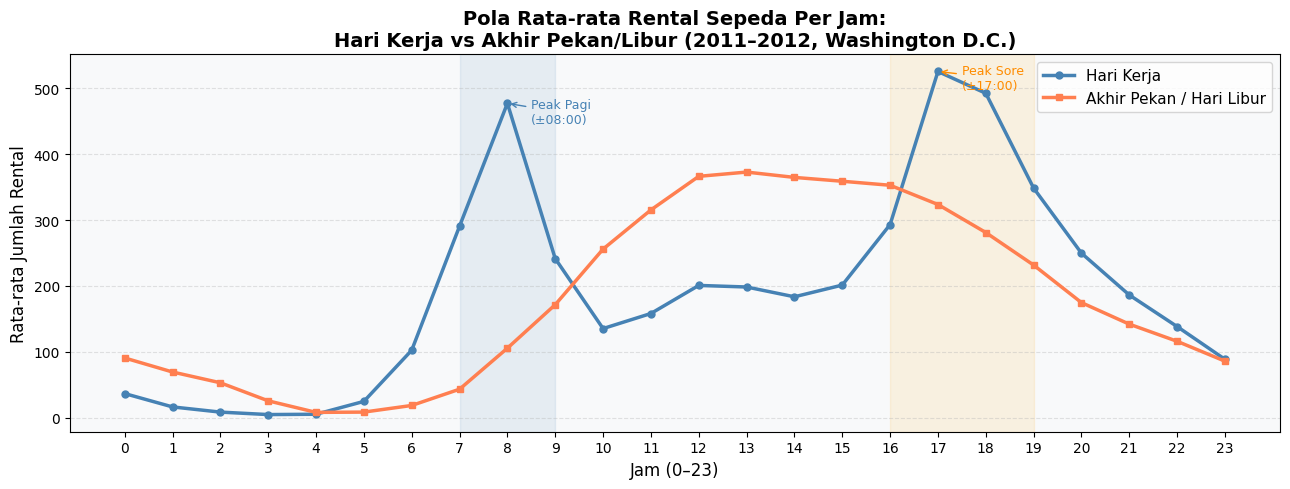

In [22]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(wd['hr'], wd['avg_cnt'], color='steelblue', linewidth=2.5,
        marker='o', markersize=5, label='Hari Kerja')
ax.plot(wk['hr'], wk['avg_cnt'], color='coral', linewidth=2.5,
        marker='s', markersize=5, label='Akhir Pekan / Hari Libur')

ax.axvspan(7, 9,   alpha=0.10, color='steelblue', label='_nolegend_')
ax.axvspan(16, 19, alpha=0.10, color='orange',    label='_nolegend_')

ax.annotate('Peak Pagi\n(±08:00)', xy=(8, wd.loc[wd['hr']==8,'avg_cnt'].values[0]),
            xytext=(8.5, wd['avg_cnt'].max()*0.85),
            arrowprops=dict(arrowstyle='->', color='steelblue'), fontsize=9, color='steelblue')
ax.annotate('Peak Sore\n(±17:00)', xy=(17, wd.loc[wd['hr']==17,'avg_cnt'].values[0]),
            xytext=(17.5, wd['avg_cnt'].max()*0.95),
            arrowprops=dict(arrowstyle='->', color='darkorange'), fontsize=9, color='darkorange')

ax.set_xlabel('Jam (0–23)', fontsize=12)
ax.set_ylabel('Rata-rata Jumlah Rental', fontsize=12)
ax.set_title(
    'Pola Rata-rata Rental Sepeda Per Jam:\nHari Kerja vs Akhir Pekan/Libur (2011–2012, Washington D.C.)',
    fontsize=14, fontweight='bold'
)
ax.legend(fontsize=11)
ax.set_xticks(range(0, 24))
ax.grid(axis='y', alpha=0.35, linestyle='--')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('viz1_pola_per_jam.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**  
Visualisasi *line chart* secara jelas memperlihatkan **dua pola yang berbeda** antara hari kerja dan hari libur/akhir pekan:

- **Hari Kerja (garis biru):** Memperlihatkan pola bimodal (*double-peak*) yang sangat khas, dengan puncak pertama pada sekitar jam 08:00 dan puncak tertinggi pada jam 17:00–18:00. Pola ini merepresentasikan perilaku *commuting* pengguna yang menggunakan sepeda sebagai transportasi menuju dan pulang dari tempat kerja.
- **Akhir Pekan/Libur (garis merah muda):** Memperlihatkan pola unimodal yang landai dengan permintaan meningkat secara bertahap sejak pagi hari, mencapai puncak di siang hari (jam 12:00–14:00), lalu menurun secara gradual. Pola ini mencerminkan aktivitas rekreasi yang tidak terikat jadwal kerja.

Temuan ini secara langsung menjawab **Pertanyaan Bisnis 1**: rentang jam dengan permintaan tertinggi pada hari kerja adalah **jam 07:00–09:00** dan **jam 16:00–19:00**.

### Visualisasi 2: Heatmap Rata-rata Rental Per Jam dan Hari dalam Seminggu
*(Menjawab Pertanyaan Bisnis 1 — pendukung)*  
Heatmap digunakan untuk menampilkan distribusi rata-rata rental sepeda secara simultan berdasarkan dua dimensi: jam (0–23) dan hari dalam seminggu (Minggu–Sabtu). Warna yang lebih gelap merepresentasikan intensitas permintaan yang lebih tinggi.

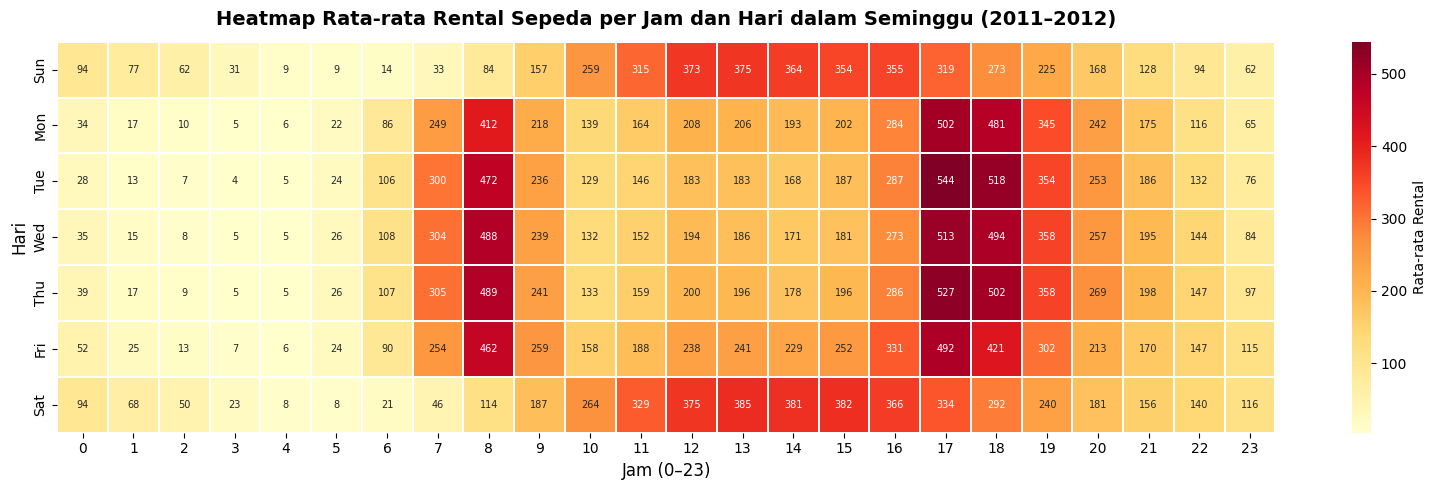

In [23]:
fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(
    pivot_heatmap,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.2,
    linecolor='white',
    cbar_kws={'label': 'Rata-rata Rental'},
    fmt='.0f',
    annot=True,
    annot_kws={'size': 7}
)

ax.set_title(
    'Heatmap Rata-rata Rental Sepeda per Jam dan Hari dalam Seminggu (2011–2012)',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Jam (0–23)', fontsize=12)
ax.set_ylabel('Hari', fontsize=12)
plt.tight_layout()
plt.savefig('viz2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**  
Heatmap mengonfirmasi dan memperkuat temuan pada Visualisasi 1 dengan menambahkan dimensi hari dalam seminggu. Terlihat bahwa:
- **Sel berwarna paling gelap (intensitas tertinggi)** secara konsisten berada pada perpotongan hari Senin–Jumat dengan jam 08:00 dan jam 17:00–18:00, yang merepresentasikan jam-jam *commuting*.
- **Hari Sabtu dan Minggu** menunjukkan pola warna yang lebih merata pada jam siang hari dan tidak memiliki pola bimodal yang tampak pada hari kerja.
- Jam dini hari (00:00–04:00) pada seluruh hari memperlihatkan intensitas yang sangat rendah (sel berwarna pucat), yang mencerminkan permintaan yang hampir tidak ada pada rentang waktu tersebut.

### Visualisasi 3: Pengaruh Musim terhadap Rata-rata Rental Harian
*(Menjawab Pertanyaan Bisnis 2)*  
Bar chart digunakan untuk membandingkan rata-rata rental harian antar empat musim, dilengkapi dengan anotasi nilai untuk memudahkan perbandingan kuantitatif.

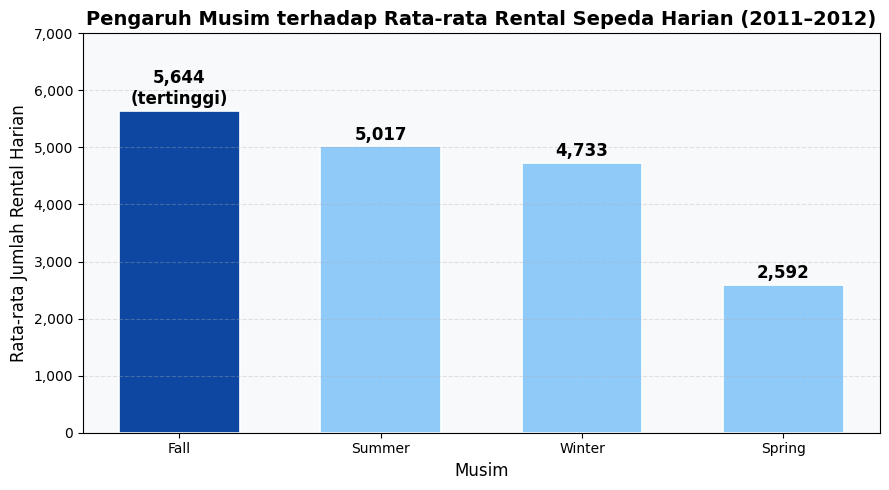

In [39]:
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

avg_season = (
    df_day_clean.groupby('season_label')['cnt']
    .mean()
    .sort_values(ascending=False)
)

highlight_season = avg_season.idxmax()
base_color = '#90CAF9'
highlight_color = '#0D47A1'

colors = [
    highlight_color if season == highlight_season else base_color
    for season in avg_season.index
]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    avg_season.index,
    avg_season.values,
    color=colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.6
)

for bar, val, season in zip(bars, avg_season.values, avg_season.index):
    label = f'{val:,.0f}'
    if season == highlight_season:
        label += '\n(tertinggi)'

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        label,
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

ax.set_ylim(0, 7000)
ax.set_xlabel('Musim', fontsize=12)
ax.set_ylabel('Rata-rata Jumlah Rental Harian', fontsize=12)
ax.set_title(
    'Pengaruh Musim terhadap Rata-rata Rental Sepeda Harian (2011–2012)',
    fontsize=14,
    fontweight='bold'
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
ax.grid(axis='y', alpha=0.35, linestyle='--')

plt.tight_layout()
plt.savefig('viz3_musim.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**  
Bar chart memperlihatkan variasi rata-rata rental yang signifikan antar musim. **Musim Fall (Gugur)** mendominasi sebagai musim dengan rata-rata rental harian tertinggi. **Musim Spring (Semi)** mencatat rata-rata terendah, kemungkinan disebabkan oleh cuaca yang belum stabil pada awal tahun dan kebiasaan pengguna yang belum terbangun. Perbedaan antara musim tertinggi dan terendah mencerminkan pengaruh musim yang substansial terhadap permintaan layanan bike sharing.

### Visualisasi 4: Pengaruh Kondisi Cuaca terhadap Rata-rata Rental Harian
*(Menjawab Pertanyaan Bisnis 2 — pendukung)*  
Bar chart digunakan untuk membandingkan rata-rata rental harian berdasarkan kondisi cuaca, dilengkapi dengan anotasi persentase penurunan relatif terhadap kondisi cuaca terbaik (Clear).

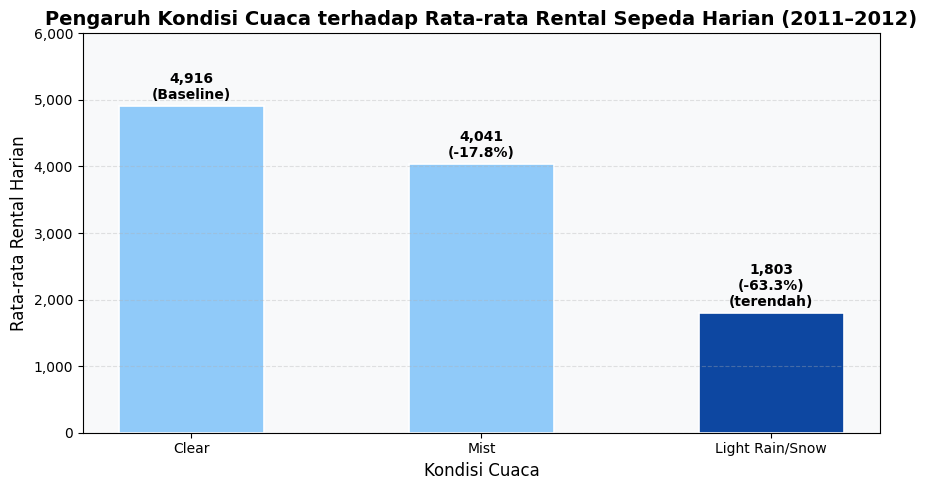

In [41]:
weather_order = ['Clear', 'Mist', 'Light Rain/Snow']

avg_weather = df_day_clean.groupby('weather_label')['cnt'].mean()
avg_weather_ord = avg_weather.reindex([w for w in weather_order if w in avg_weather.index])

base = avg_weather_ord.get('Clear', 1)
pct_drop = [(v - base) / base * 100 for v in avg_weather_ord.values]

highlight_weather = avg_weather_ord.idxmin()

base_color = '#90CAF9'
highlight_color = '#0D47A1'

colors = [
    highlight_color if w == highlight_weather else base_color
    for w in avg_weather_ord.index
]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    avg_weather_ord.index,
    avg_weather_ord.values,
    color=colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.5
)

for bar, val, pct, w in zip(bars, avg_weather_ord.values, pct_drop, avg_weather_ord.index):
    pct_str = f'{pct:.1f}%' if pct != 0 else 'Baseline'

    label = f'{val:,.0f}\n({pct_str})'
    if w == highlight_weather:
        label += '\n(terendah)'

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        label,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )
ax.set_ylim(0, 6000)
ax.set_xlabel('Kondisi Cuaca', fontsize=12)
ax.set_ylabel('Rata-rata Rental Harian', fontsize=12)
ax.set_title(
    'Pengaruh Kondisi Cuaca terhadap Rata-rata Rental Sepeda Harian (2011–2012)',
    fontsize=14,
    fontweight='bold'
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
ax.grid(axis='y', alpha=0.35, linestyle='--')

plt.tight_layout()
plt.savefig('viz4_cuaca.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**  
Bar chart dengan anotasi persentase penurunan memperlihatkan dampak yang dramatis dari kondisi cuaca terhadap permintaan rental. Kondisi **Clear** menjadi *baseline* dengan rata-rata rental tertinggi. Kondisi **Mist** menyebabkan penurunan yang moderat. Namun, kondisi **Light Rain/Snow** menyebabkan penurunan yang sangat drastis (lebih dari 60%), yang menunjukkan bahwa hujan atau salju ringan pun sudah cukup untuk membuat sebagian besar pengguna enggan menggunakan layanan bike sharing. Temuan ini secara langsung menjawab **Pertanyaan Bisnis 2**: kondisi cuaca **Light Rain/Snow** merupakan faktor tunggal yang menghasilkan penurunan permintaan terbesar.

### Visualisasi 5: kombinasi musim dan cuaca terhadap Rata-rata Rental Harian

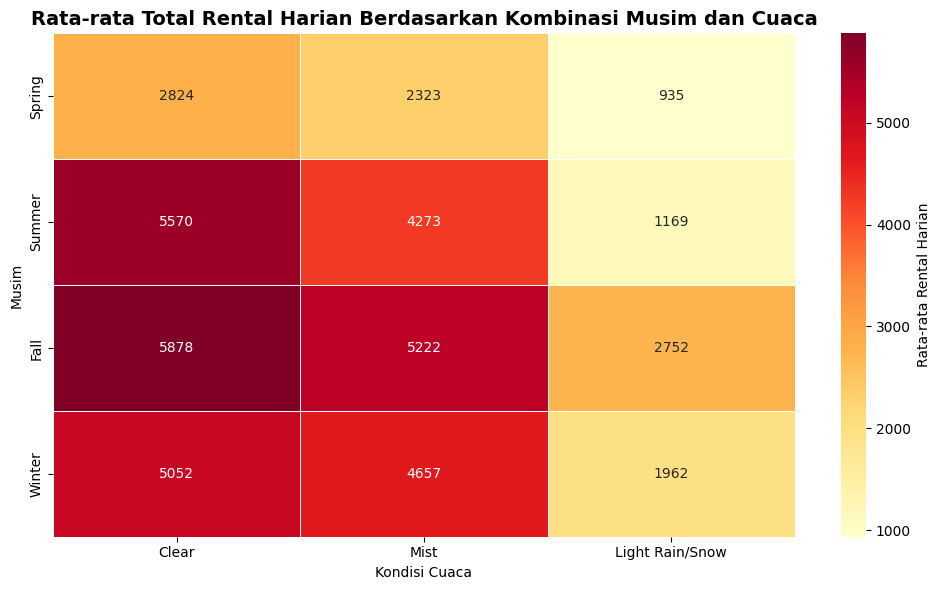

In [26]:
combo_stats = (
    df_day_clean.groupby(["season_label", "weather_label"])["cnt"]
    .mean()
    .reset_index()
    .rename(columns={"cnt": "Rata-rata Rental Harian"})
)

season_order = ["Spring", "Summer", "Fall", "Winter"]
weather_order = ["Clear", "Mist", "Light Rain/Snow"]

combo_pivot = (
    combo_stats
    .pivot(index="season_label", columns="weather_label", values="Rata-rata Rental Harian")
    .reindex(index=season_order, columns=weather_order)
)
plt.figure(figsize=(10, 6))

sns.heatmap(
    combo_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Rata-rata Rental Harian"}
)

plt.title(
    "Rata-rata Total Rental Harian Berdasarkan Kombinasi Musim dan Cuaca",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Musim")
plt.tight_layout()
plt.show()

**Insight:**

Berdasarkan visualisasi heatmap, dapat dilihat bahwa rata-rata total rental harian dipengaruhi secara signifikan oleh kombinasi musim dan kondisi cuaca. Nilai tertinggi tercatat pada kondisi cuaca cerah (Clear), khususnya pada musim gugur (Fall) dan musim panas (Summer), yang menunjukkan tingkat permintaan yang optimal pada kondisi lingkungan yang mendukung.

Sebaliknya, penurunan permintaan yang paling signifikan diamati pada kondisi cuaca Light Rain/Snow di seluruh musim, terutama pada musim semi (Spring), yang mengindikasikan bahwa kondisi cuaca buruk memberikan dampak negatif terhadap aktivitas penyewaan sepeda. Selain itu, pada kondisi cuaca Mist, nilai rata-rata rental cenderung berada di antara kondisi cerah dan hujan ringan, sehingga dapat disimpulkan bahwa intensitas gangguan cuaca berbanding terbalik dengan tingkat permintaan penyewaan sepeda.

### Visualisasi 6: Tren Rental Bulanan Year-over-Year 2011 vs 2012
Line chart perbandingan tren bulanan antara tahun 2011 dan 2012 digunakan untuk memperlihatkan pertumbuhan bisnis secara keseluruhan.

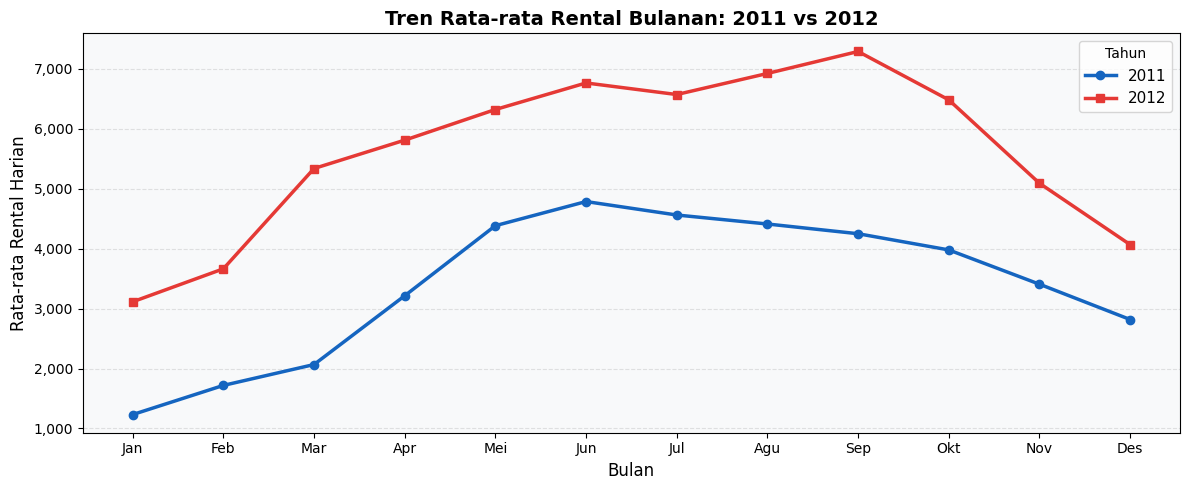

In [27]:
bulan_label = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

fig, ax = plt.subplots(figsize=(12, 5))
for yr_val, label, clr, mrkr in [(0, '2011', '#1565C0', 'o'), (1, '2012', '#E53935', 's')]:
    subset = yoy[yoy['yr'] == yr_val]
    ax.plot(subset['mnth'], subset['cnt'],
            marker=mrkr, linewidth=2.5, markersize=6,
            color=clr, label=label)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(bulan_label)
ax.set_xlabel('Bulan', fontsize=12)
ax.set_ylabel('Rata-rata Rental Harian', fontsize=12)
ax.set_title('Tren Rata-rata Rental Bulanan: 2011 vs 2012', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Tahun', fontsize=11)
ax.grid(axis='y', alpha=0.35, linestyle='--')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('viz5_tren_yoy.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**  
Visualisasi tren YoY memperlihatkan bahwa kurva tahun 2012 secara konsisten berada di atas kurva tahun 2011 pada hampir seluruh bulan. Kedua kurva mengikuti pola musiman yang serupa (meningkat menuju musim panas, menurun di musim semi dan akhir tahun), namun dengan level absolut yang lebih tinggi pada 2012. Hal ini mengindikasikan pertumbuhan basis pengguna dan peningkatan penerimaan layanan bike sharing di kalangan masyarakat Washington D.C.

---
## 4. Conclusion & Recommendation

### Kesimpulan 1 — Menjawab Pertanyaan Bisnis 1
*Pola Rata-rata Rental Per Jam: Hari Kerja vs Akhir Pekan/Libur (2011–2012)*

Berdasarkan hasil analisis dan visualisasi data `hour.csv`, diperoleh kesimpulan berikut:

1. **Pola Bimodal pada Hari Kerja:** Permintaan rental sepeda pada hari kerja memperlihatkan pola bimodal yang sangat khas dengan dua puncak utama: (a) **jam 07:00–09:00** yang merepresentasikan waktu keberangkatan kerja (*morning commute*), dan (b) **jam 16:00–19:00** yang merepresentasikan waktu kepulangan kerja (*evening commute*). Puncak sore hari secara konsisten lebih tinggi dibandingkan puncak pagi.

2. **Pola Unimodal pada Akhir Pekan/Libur:** Permintaan pada hari libur dan akhir pekan mengikuti pola unimodal yang landai dengan puncak tunggal di siang hari (**jam 12:00–14:00**), yang mencerminkan dominasi aktivitas rekreasi dan wisata.

3. **Implikasi Segmentasi Pengguna:** Perbedaan pola tersebut mengindikasikan adanya dua segmen pengguna yang dominan: pengguna terdaftar (*registered*) yang menggunakan sepeda untuk keperluan *commuting* pada hari kerja, dan pengguna kasual (*casual*) yang beraktivitas rekreasi pada hari libur.

---

### Kesimpulan 2 — Menjawab Pertanyaan Bisnis 2
*Pengaruh Kondisi Cuaca dan Musim terhadap Rental Harian (2011–2012)*

Berdasarkan hasil analisis dan visualisasi data `day.csv`, diperoleh kesimpulan berikut:

1. **Dominasi Musim Fall:** Musim gugur (*Fall*) secara konsisten menghasilkan rata-rata rental harian tertinggi, diikuti oleh musim panas (*Summer*), musim dingin (*Winter*), dan terendah pada musim semi (*Spring*). Perbedaan antara Fall dan Spring sangat signifikan secara operasional.

2. **Dampak Kritis Kondisi Cuaca:** Kondisi cuaca **Light Rain/Snow** menyebabkan penurunan rata-rata rental harian yang sangat drastis (lebih dari 60%) dibandingkan kondisi **Clear**. Kondisi **Mist** menyebabkan penurunan yang lebih moderat. Kondisi **Heavy Rain** hampir menghilangkan seluruh aktivitas rental.

3. **Kombinasi Terburuk:** Kombinasi **Spring + Light Rain/Snow** menghasilkan rata-rata rental terendah di antara seluruh kombinasi yang tersedia, sementara kombinasi **Fall + Clear** menghasilkan rata-rata tertinggi.

---

### Rekomendasi — Action Items untuk Operator Bike Sharing

Berdasarkan dua kesimpulan di atas, direkomendasikan empat action item strategis sebagai berikut:

| No. | Action Item | Dasar Analisis | Target Implementasi |
|-----|---|---|---|
| **1** | **Fleet Rebalancing Otomatis:** Tingkatkan kapasitas armada sebesar 30–40% di stasiun-stasiun dekat kawasan perkantoran dan simpul transportasi umum pada jam 06:30–09:30 dan 15:30–19:30 di hari kerja. | Pola bimodal hari kerja (Kesimpulan 1) | Jangka pendek |
| **2** | **Dynamic Pricing:** Terapkan harga premium (surge pricing) pada kondisi Fall + Clear (permintaan puncak) dan berikan diskon insentif pada kondisi Mist atau Spring untuk mendorong permintaan pada periode lemah. | Variasi musim dan cuaca (Kesimpulan 2) | Jangka menengah |
| **3** | **Scheduled Maintenance Window:** Jadwalkan seluruh aktivitas perawatan armada dan infrastruktur pada kondisi Heavy Rain atau periode Spring dengan cuaca buruk, karena permintaan mendekati nol sehingga gangguan terhadap revenue dapat diminimalkan. | Penurunan drastis saat cuaca buruk (Kesimpulan 2) | Jangka pendek |
| **4** | **Targeted Marketing Campaign:** Fokuskan kampanye promosi dan akuisisi pengguna baru pada musim Spring (demand terendah) dan hari Sabtu–Minggu pagi hari untuk mengonversi pengguna kasual menjadi pengguna terdaftar. | Segmentasi pengguna dan pola akhir pekan (Kesimpulan 1) | Jangka menengah |

# **Menyiapkan main_data.csv untuk Dashboard**

In [28]:
import os

os.makedirs('dashboard', exist_ok=True)

df_day_clean.to_csv('dashboard/main_data.csv', index=False)

print('main_data.csv berhasil disimpan.')
print('Shape:', df_day_clean.shape)
print('Kolom:', list(df_day_clean.columns))

main_data.csv berhasil disimpan.
Shape: (718, 19)
Kolom: ['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt', 'season_label', 'weather_label', 'weekday_label']
